# Exploratory Data Analysis – CBCL Severity Prediction

This notebook explores the dataset used to predict child CBCL severity from parent-written free text.

The analysis focuses on:

* the structure and composition of the study sample,
* the distribution of CBCL outcomes,
* characteristics of the parent-written `Event` and `EER_text` responses,
* relationships between selected demographic variables and CBCL severity, and
* lexical patterns associated with different levels of CBCL severity.

The findings from this exploratory analysis informed the preprocessing, feature selection, and modeling choices used in the subsequent baseline and transformer modeling notebooks.

## 1. Data Preparation and Sample Construction

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

### 1.1 Data Loading

In [9]:
# Loading the data
url = "https://github.com/OfriA/AppliedProject52056/raw/refs/heads/main/data/ER_data.xlsx"
data = pd.read_excel(url)

In [8]:
data.shape

(659, 344)

The raw survey dataset contains 659 observations and includes demographic variables, war-exposure measures, parent free-text responses, and child CBCL questionnaire items.

### 1.2 War-Exposure and CBCL Score Construction

In [10]:
# War exposure features
self_exposure_features = ['SelfExposure_1', 'SelfExposure_2', 'SelfExposure_3', 'SelfExposure_4', 'SelfExposure_5', 'SelfExposure_6']
other_exposure_features = ['OtherExposure_6', 'OtherExposure_7', 'OtherExposure_8', 'OtherExposure_9', 'OtherExposure_10', 'OtherExposure_11', 'OtherExposure_12']

# Commpute war exposure score
data['self_exposure_score'] = np.sum(data[self_exposure_features], axis=1)
data['other_exposure_score'] = np.sum(data[other_exposure_features], axis=1)
data['war_exposure_score'] = np.sum(data[['self_exposure_score', 'other_exposure_score']], axis=1)

In [11]:
# CBCL features
CBCL_features = data.columns[240:283].to_list()

CBCL_D_features = CBCL_features[0:13]
CBCL_A_features = CBCL_features[13:31]
CBCL_S_features = CBCL_features[31:]


# Compute CBCL score
data['CBCL_D_score'] = np.sum(data[CBCL_D_features], axis=1)
data['CBCL_A_score'] = np.sum(data[CBCL_A_features], axis=1)
data['CBCL_S_score'] = np.sum(data[CBCL_S_features], axis=1)
data['CBCL_score'] = np.sum(data[['CBCL_D_score', 'CBCL_A_score', 'CBCL_S_score']], axis=1)

### 1.3 Sample Selection

In [12]:
# Omitting NA's
data = data[np.sum(data[self_exposure_features + other_exposure_features + CBCL_features].isna(), axis=1) == 0]

In [13]:
data.shape

(363, 351)

### 1.4 Sample Characteristics

In [14]:
data[['Progress', 'Duration (in seconds)', 'sex', 'age', 'ed_level', 'ses', 'DAS_1', 'custody', 'n_children', 'child_age', 'child_gender', 'moved_Y/N', 'therapy', 'psych_drugs', 'health', 'partner_duty', 'alarms_freq', ]].describe()

,Progress,Duration (in seconds),sex,age,ed_level,ses,DAS_1,custody,n_children,child_age,child_gender,moved_Y/N,therapy,psych_drugs,health,partner_duty,alarms_freq
count,363.000000,363.000000,363.000000,363.000000,363.000000,363.000000,328.000000,19.000000,363.000000,363.000000,362.00000,363.000000,123.000000,123.000000,123.000000,362.000000,363.000000
mean,96.900826,8294.881543,1.774105,40.702479,3.506887,3.440771,5.634146,1.684211,2.716253,9.355372,1.48895,1.933884,2.715447,2.821138,3.788618,1.950276,2.721763
std,1.951363,39878.535050,0.418748,7.794294,0.653788,1.280405,1.329617,0.820070,1.202867,3.673542,0.50057,0.248827,0.659363,0.543705,0.770906,0.583961,1.502207
min,79.000000,363.000000,1.000000,7.000000,2.000000,1.000000,1.000000,1.000000,0.000000,5.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,96.000000,1142.000000,2.000000,36.000000,3.000000,3.000000,5.000000,1.000000,2.000000,6.000000,1.00000,2.000000,3.000000,3.000000,3.000000,2.000000,1.000000
50%,96.000000,1581.000000,2.000000,40.000000,4.000000,3.000000,6.000000,1.000000,3.000000,8.000000,1.00000,2.000000,3.000000,3.000000,4.000000,2.000000,3.000000
75%,97.000000,2303.500000,2.000000,45.000000,4.000000,5.000000,7.000000,2.000000,3.000000,12.000000,2.00000,2.000000,3.000000,3.000000,4.000000,2.000000,4.000000
max,100.000000,423682.000000,2.000000,99.000000,4.000000,5.000000,7.000000,3.000000,7.000000,18.000000,2.00000,2.000000,3.000000,3.000000,5.000000,4.000000,5.000000


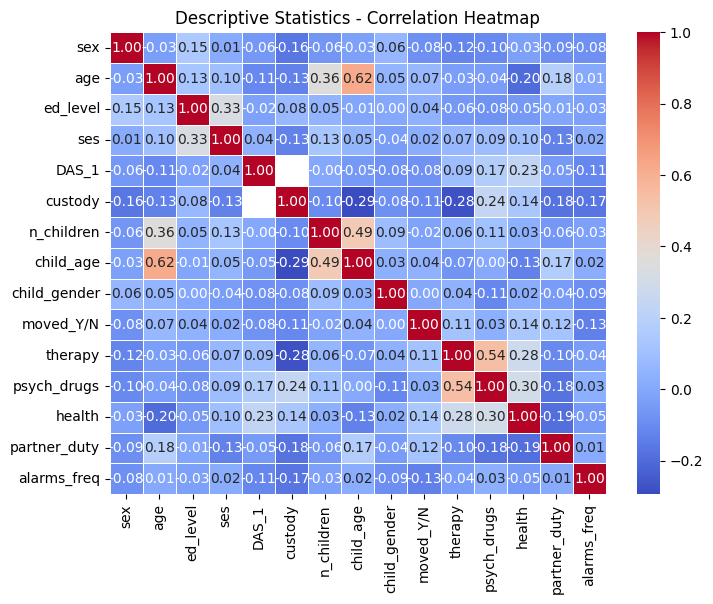

In [ ]:
descriptive_corr = data[['sex', 'age', 'ed_level', 'ses', 'DAS_1', 'custody', 'n_children', 'child_age', 'child_gender', 'moved_Y/N', 'therapy', 'psych_drugs', 'health', 'partner_duty', 'alarms_freq', ]].corr()

# Create the heatmap
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(descriptive_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Descriptive Statistics - Correlation Heatmap')
plt.show()

## 2. CBCL Analysis

### 2.1 CBCL Score Distribution

In [ ]:
print(f"CBCL mean: {data['CBCL_score'].mean():.5}, CBCL SD: {data['CBCL_score'].std():.5}")
print(f"CBCL D mean: {data['CBCL_D_score'].mean():.5}, CBCL D SD: {data['CBCL_D_score'].std():.5}")
print(f"CBCL A mean: {data['CBCL_A_score'].mean():.5}, CBCL A SD: {data['CBCL_A_score'].std():.5}")
print(f"CBCL S mean: {data['CBCL_S_score'].mean():.5}, CBCL S SD: {data['CBCL_S_score'].std():.5}")


CBCL mean: 16.62, CBCL SD: 13.912
CBCL D mean: 6.5372, CBCL D SD: 4.9929
CBCL A mean: 7.5372, CBCL A SD: 7.398
CBCL S mean: 2.5455, CBCL S SD: 3.6345


### 2.2 CBCL and Child Age

In [ ]:
data['child_age'] = np.int16(data['child_age'])

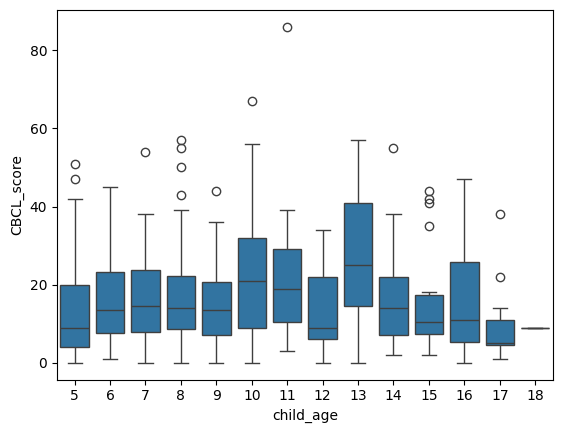

In [ ]:
ax = sns.boxplot(data=data, x='child_age', y='CBCL_score')



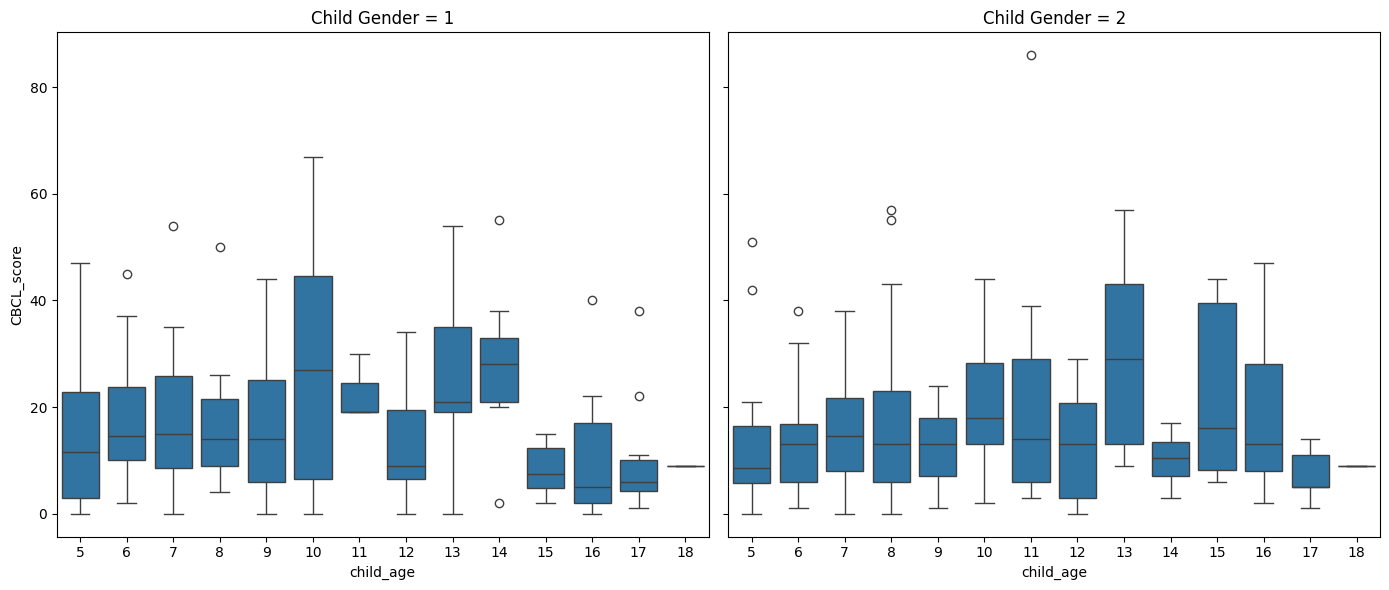

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# child_gender == 1
sns.boxplot(
    data=data[data['child_gender'] == 1],
    x='child_age', y='CBCL_score',
    ax=axes[0]
)
axes[0].set_title('Child Gender = 1')

# child_gender == 2
sns.boxplot(
    data=data[data['child_gender'] == 2],
    x='child_age', y='CBCL_score',
    ax=axes[1]
)
axes[1].set_title('Child Gender = 2')

plt.tight_layout()
plt.show()

## 3. Text Analysis

### 3.1 Text Length

In [ ]:
# Compute length of texts
data['Event_length'] = data['Event'].str.len()
data['EER_text_length'] = data['EER_text'].str.len()

data['EER_text_length'] = data['EER_text_length'].fillna(0)


In [ ]:
print(f"Event length mean: {data['Event_length'].mean():.5}, Event length SD: {data['Event_length'].std():.5}")
print(f"EER text length mean: {data['EER_text_length'].mean():.5}, EER text length SD: {data['EER_text_length'].std():.5}")

Event length mean: 124.44, Event length SD: 101.91
EER text length mean: 85.338, EER text length SD: 113.42


### 3.2 CBCL Score Vs. Text Length

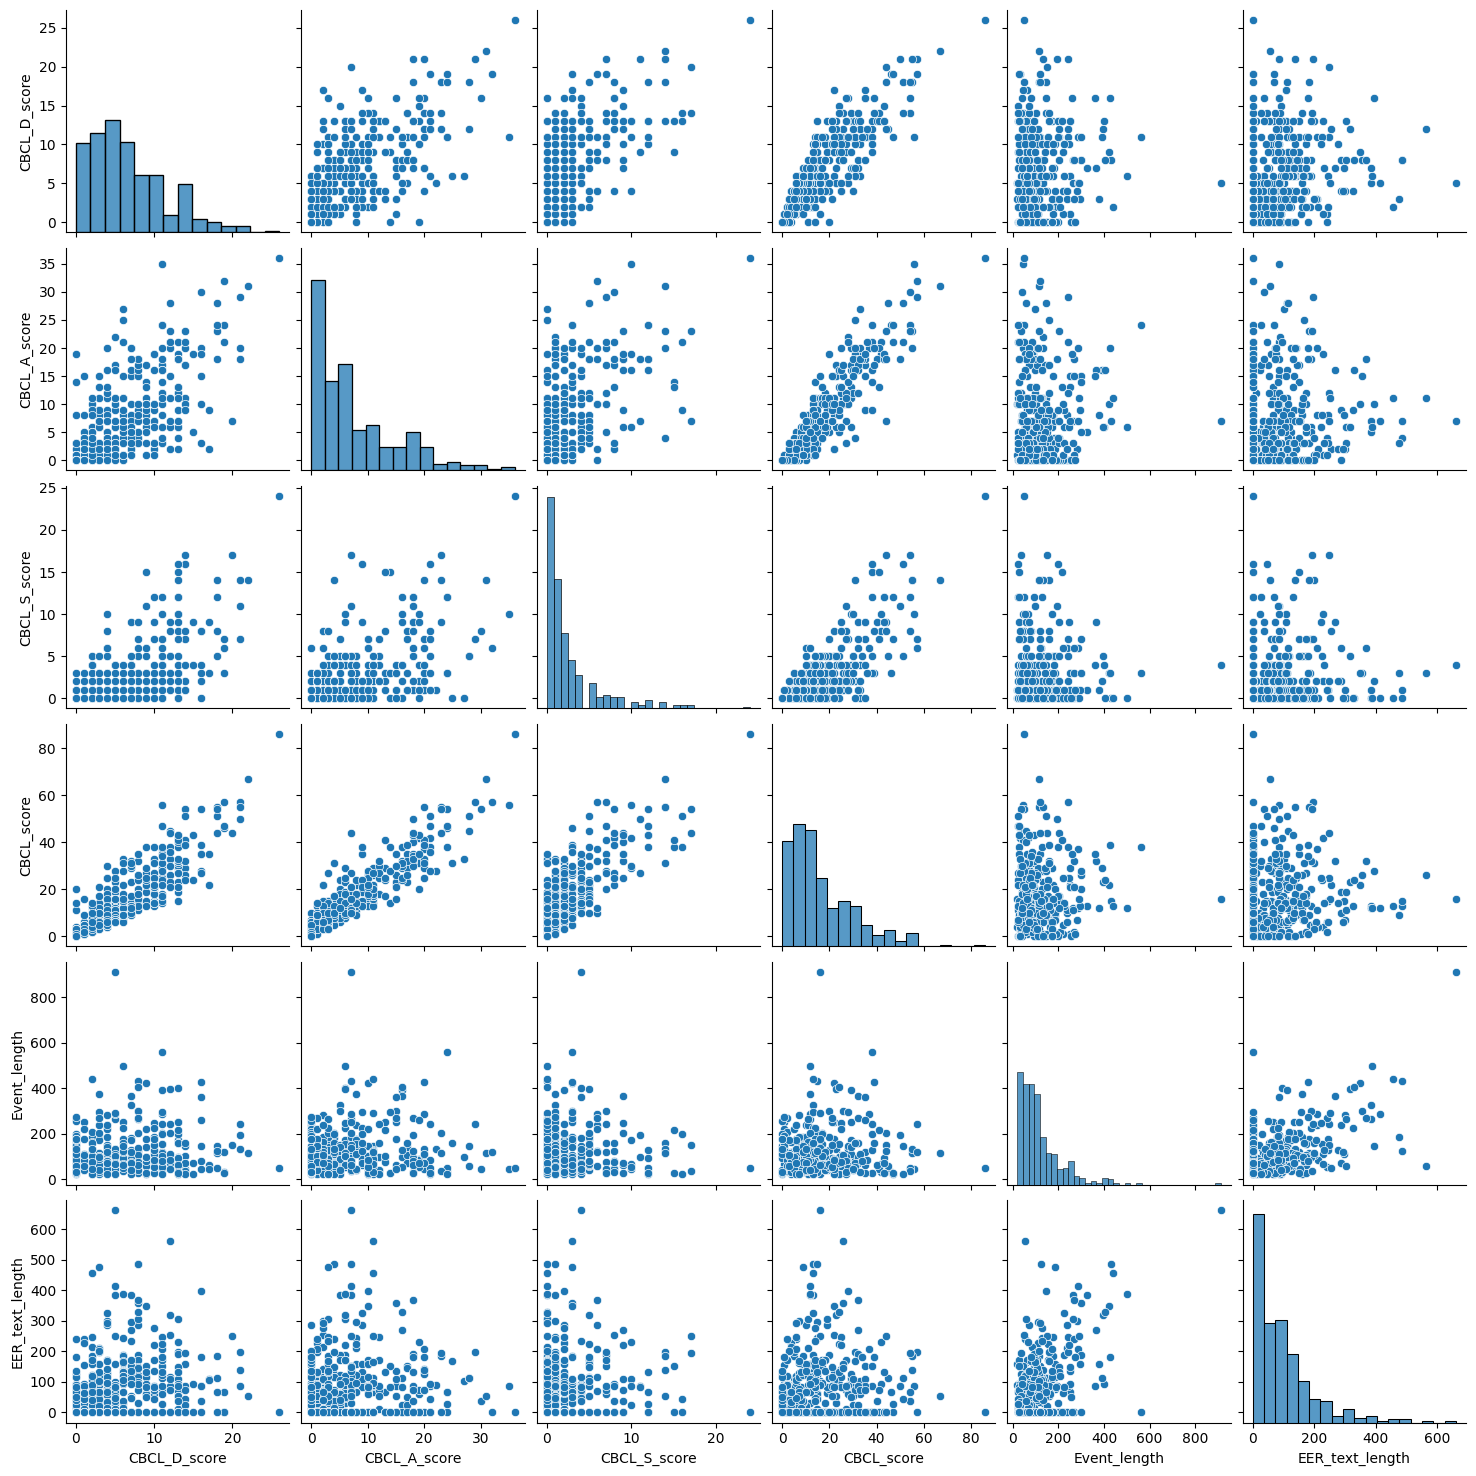

In [ ]:
sns.pairplot(data[['CBCL_D_score', 'CBCL_A_score', 'CBCL_S_score', 'CBCL_score', 'Event_length', 'EER_text_length']])

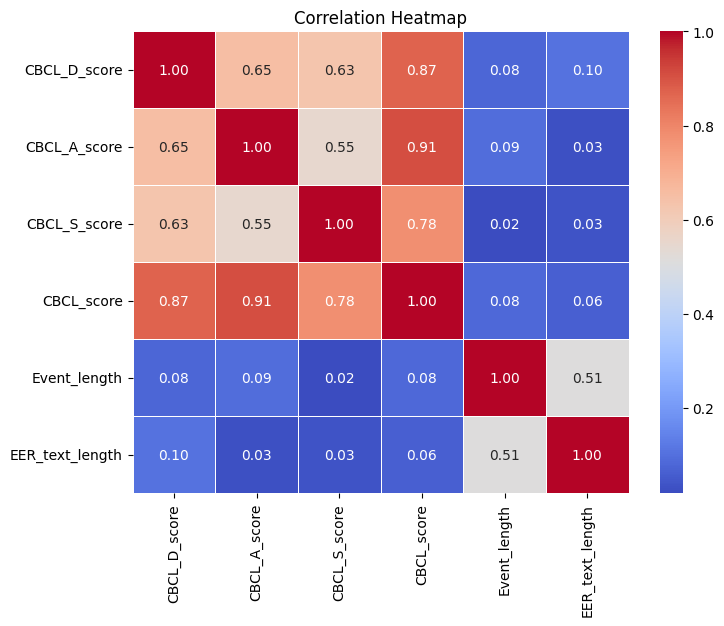

In [ ]:
corr_matrix = data[['CBCL_D_score', 'CBCL_A_score', 'CBCL_S_score', 'CBCL_score', 'Event_length', 'EER_text_length']].corr()

# Create the heatmap
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

### 3.3 Hebrew Text Preprocessing

Because the free-text responses are written in Hebrew, the texts were tokenized and lemmatized using Stanza. Common function words, detached prefixes, punctuation, and other non-informative tokens were then removed before the lexical analysis.

In [17]:
# 1. Install Stanza (Run this once)
!pip install stanza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.2/794.2 kB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 34.7 MB/s eta 0:00:00


In [18]:
data['combined_texts'] = data['Event'] + [" "] * len(data['Event']) + data['EER_text']

In [19]:
import stanza

# Download the Hebrew model (Run this once)
# This downloads the pre-trained neural network for Hebrew
stanza.download('he')

# Initialize the pipeline
# We need 'tokenize' (split words), 'mwt' (multi-word token expansion), and 'lemma' (base forms)
nlp = stanza.Pipeline(lang='he', processors='tokenize,mwt,pos,lemma', use_gpu=True)

# Define the Lemmatization Function
def get_hebrew_lemmas(text):
    if not isinstance(text, str) or not text.strip():
        return []

    # Process the text with Stanza
    doc = nlp(text)

    lemmas = []
    # Stanza organizes text into sentences -> words
    for sent in doc.sentences:
        for word in sent.words:
            # 'word.lemma' is the base form (e.g., 'הלכנו' -> 'הלך')
            # We filter out punctuation manually if needed
            if word.upos != 'PUNCT':
                lemmas.append(word.lemma)
    return lemmas

# --- APPLY TO YOUR DATAFRAME ---
# Assuming your dataframe is called 'data' and the text column is 'text_column'

# (Replace 'text_column' with the actual name of your column, e.g., 'description')
column_name = 'combined_texts'

# This might take a few minutes depending on the size of your data
print("Processing text... this may take a while for large datasets.")
data['lemmas'] = data[column_name].apply(get_hebrew_lemmas)

# --- INSPECT RESULTS ---
print(data[[column_name, 'lemmas']].head())

INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/resources.json
INFO:stanza:Downloading default packages for language: he (Hebrew) ...


models/default.zip: reconstructing file:   0%|          |  0.00B /  344MB            

models/default.zip: downloading bytes:           |  0.00B            

INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/he/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.14.0/resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/resources.json
INFO:stanza:Loading these models for language: he (Hebrew):
| Processor | Package           |
---------------------------------
| tokenize  | combined_nocharlm |
| mwt       | combined          |
| pos       | combined_charlm   |
| lemma     | combined_nocharlm |

INFO:stanza:Using device: cuda
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Done loading processors!


Processing text... this may take a while for large datasets.
                                      combined_texts  \
0  שיחקתי עם הבן שלי ואז צחק וחייך, והדבר היחיד ש...   
1  באמצע חגיגת יום הולדת ביתית לביתי בת ה6, אחותה...   
3  התיסכול בין לריב איתם על להיתחבר לזום להין לוו...   
4  נבהלתי מאוד מהאזעקות הרבות, הילדים הרגישו את ה...   
7  הרבה תסכול וחוסר אונים, מחשבות על הילדים הפרטי...   

                                              lemmas  
0  [שיחק, עם, ה, בן, של, הוא, ו, אז, צחק, ו, חייך...  
1  [ב, אמצע, חגיגה, יום, הולדת, ביתי, ל, בית, הוא...  
3  [ה, תסכול, בין, רב, את, הוא, על, נתחבר, ל, זום...  
4  [נבהל, מאוד, מ, ה, אזעקה, ה, רב, ה, ילד, הרגיש...  
7  [הרבה, תסכול, ו, חוסר, און, מחשבה, על, ה, ילד,...  


### 3.4 Overall Word Frequencies

/tmp/ipykernel_4145/2655002832.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words_reversed, palette='viridis')


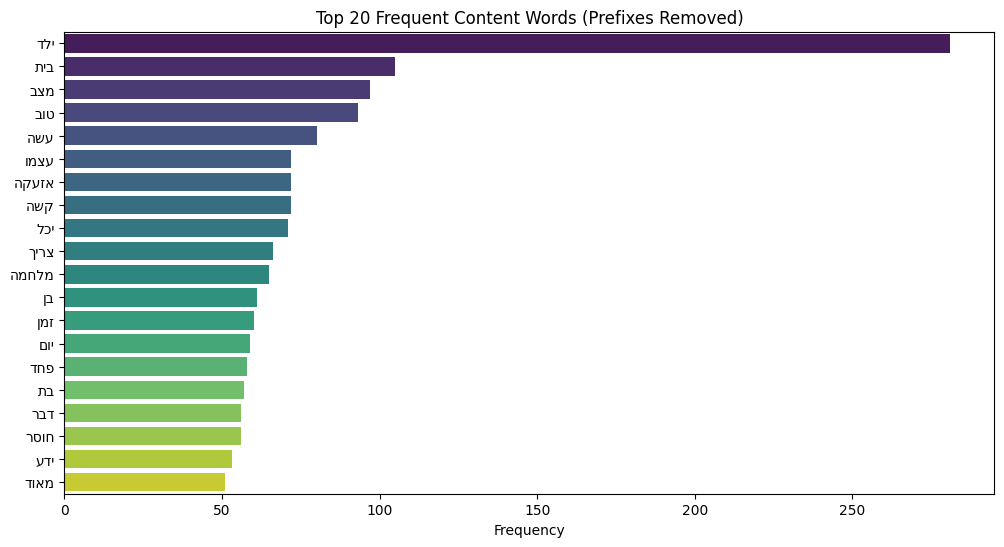

In [20]:
# 1. Define Hebrew Stopwords & Prefixes to Ignore
# This list includes single-letter prefixes (handled by Stanza splitting)
# and common function words irrelevant to the semantic analysis.
ignore_words = {
    # Prefixes (often separated by Stanza)
    'ה', 'ו', 'ב', 'ל', 'ש', 'מ', 'כ', 'כש',
    # Pronouns & Function words
    'אני', 'את', 'אתה', 'אנחנו', 'הוא', 'כול', 'היא', 'הם', 'הן',
    'זה', 'זאת', 'אלו', 'של', 'על', 'מה', 'עם', 'כל', 'רק', 'אבל',
    'או', 'אם', 'גם', 'לא', 'כן', 'כי', 'אז', 'יותר', 'פחות',
    'היה', 'הייתה', 'היו', 'יש', 'אין', 'לי', 'לו', 'לה', 'לנו'
}

def filter_prefixes(lemma_list):
    """
    Filters out prefixes, single letters, and stopwords.
    Returns a clean list of content words.
    """
    if not isinstance(lemma_list, list):
        return []

    # Keep word if:
    # 1. It is not in the ignore list
    # 2. It is longer than 1 character (removes remaining detached prefixes)
    # 3. It is alphabetical (removes punctuation)
    return [word for word in lemma_list
            if word not in ignore_words
            and len(word) > 1
            and word.isalpha()]

# 2. Apply Filtering
# Assumes 'lemmas' is the column from the previous Stanza step
data['clean_content'] = data['lemmas'].apply(filter_prefixes)

# 3. Flatten list for global statistics
all_words = [word for sublist in data['clean_content'] for word in sublist]
word_counts = Counter(all_words)

# --- Top 20 Most Frequent Content Words ---

# Get top 20 words
top_words = word_counts.most_common(20)
words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

# Reverse Hebrew strings for correct display in Matplotlib
words_reversed = [w[::-1] for w in words]

plt.figure(figsize=(12, 6))
sns.barplot(x=counts, y=words_reversed, palette='viridis')
plt.title('Top 20 Frequent Content Words (Prefixes Removed)')
plt.xlabel('Frequency')
plt.show()



### 3.5 Word Frequencies by CBCL Severity

In [21]:
# define High as top 15% (change 0.85 -> 0.90 for top 10%, 0.80 for top 20%)
t1 = np.quantile(data['CBCL_score'], 0.50)
t2 = np.quantile(data['CBCL_score'], 0.85)


def cbcl_to_group(y):
    # returns array of strings: "Low", "Medium", "High"
    y = np.asarray(y)
    return np.where(y <= t1, "Low",
                    np.where(y <= t2, "Medium", "High"))

In [22]:
data['CBCL_label'] = cbcl_to_group(data['CBCL_score'])

In [25]:
# Flatten words with labels
rows = []
for _, row in data.iterrows():
    for word in row['clean_content']:
        rows.append({
            'word': word,
            'CBCL_label': row['CBCL_label']
        })

df_words = pd.DataFrame(rows)

# Get top N words overall
top_n = 10
top_words = (
    df_words['word']
    .value_counts()
    .head(top_n)
    .index
)

df_top = df_words[df_words['word'].isin(top_words)]


word_label_counts = (
    df_top
    .groupby(['word', 'CBCL_label'])
    .size()
    .reset_index(name='count')
)


word_label_counts['word_rtl'] = word_label_counts['word'].apply(lambda w: w[::-1])


word_label_counts['normalized'] = (
    word_label_counts
    .groupby('CBCL_label')['count']
    .transform(lambda x: x / x.sum())
)


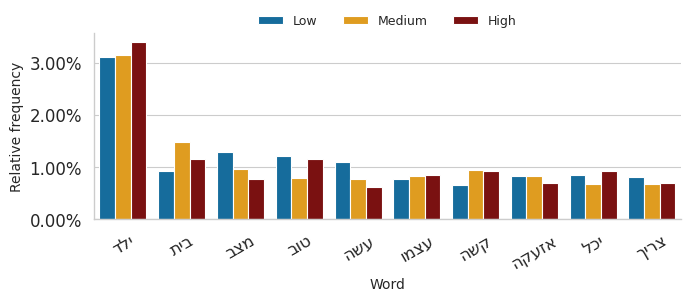

In [ ]:
from matplotlib.ticker import PercentFormatter

# --------------------------------------------------
# Total number of words in each CBCL group
# --------------------------------------------------
total_words_by_label = (
    df_words
    .groupby('CBCL_label')
    .size()
    .to_dict()
)

# --------------------------------------------------
# Top N words overall
# --------------------------------------------------
top_n = 10

top_words = (
    df_words['word']
    .value_counts()
    .head(top_n)
    .index
)

df_top = df_words[df_words['word'].isin(top_words)]

word_label_counts = (
    df_top
    .groupby(['word', 'CBCL_label'])
    .size()
    .reset_index(name='count')
)

# Hebrew display
word_label_counts['word_rtl'] = (
    word_label_counts['word']
    .apply(lambda w: w[::-1])
)

# --------------------------------------------------
# True relative frequency:
# count of word / all words in that CBCL group
# --------------------------------------------------
word_label_counts['normalized'] = (
    word_label_counts.apply(
        lambda row:
        row['count'] / total_words_by_label[row['CBCL_label']],
        axis=1
    )
)

# Preserve overall word-frequency order on x-axis
word_order = [w[::-1] for w in top_words]

# --------------------------------------------------
# Publication-style figure
# --------------------------------------------------
sns.set_theme(style="whitegrid", context="paper")

fig, ax = plt.subplots(figsize=(7.0, 3.2))

sns.barplot(
    data=word_label_counts,
    x='word_rtl',
    y='normalized',
    hue='CBCL_label',
    order=word_order,
    hue_order=['Low', 'Medium', 'High'],
    palette={
        'Low': '#0072B2',
        'Medium': 'orange',
        'High': '#8B0000'
    },
    errorbar=None,
    ax=ax
)

# No internal title — caption will be in the paper
ax.set_xlabel('Word', fontsize=10)
ax.set_ylabel('Relative frequency', fontsize=10)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.tick_params(axis='x', labelsize=12, rotation=30)
ax.tick_params(axis='y', labelsize=12)

ax.legend(
    title=None,
    ncol=3,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.16),
    frameon=False,
    fontsize=9
)

sns.despine(ax=ax)

plt.tight_layout()

# Vector format — preferable for Overleaf
plt.savefig(
    'word_frequencies.pdf',
    bbox_inches='tight'
)

# Optional PNG backup
plt.savefig(
    'word_frequencies.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

/tmp/ipython-input-987387190.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-987387190.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-987387190.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-987387190.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-987387190.py:72: FutureWarning: 

Passing `pa

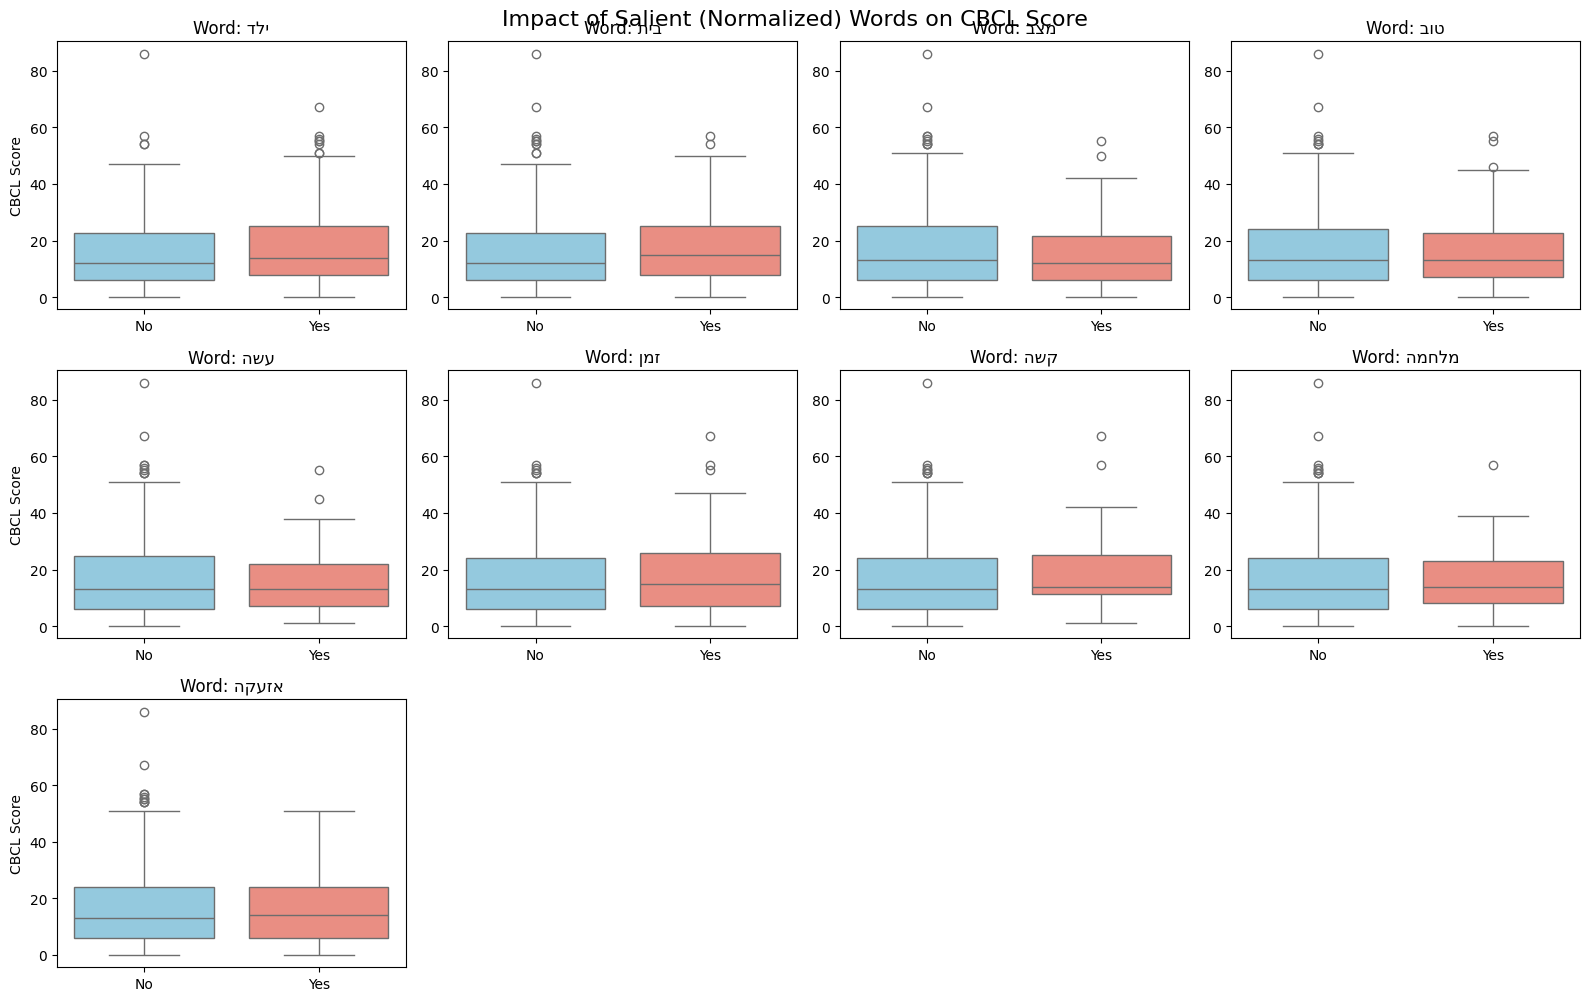

In [ ]:
# Flatten words with CBCL labels
rows = []
for _, row in data.iterrows():
    for word in row['clean_content']:
        rows.append({
            'word': word,
            'CBCL_label': row['CBCL_label']
        })

df_words = pd.DataFrame(rows)


word_counts = (
    df_words
    .groupby(['CBCL_label', 'word'])
    .size()
    .reset_index(name='count')
)

word_counts['normalized'] = (
    word_counts
    .groupby('CBCL_label')['count']
    .transform(lambda x: x / x.sum())
)


top_k = 5

top_words_per_label = (
    word_counts
    .sort_values(['CBCL_label', 'normalized'], ascending=[True, False])
    .groupby('CBCL_label')
    .head(top_k)
)


target_words = top_words_per_label['word'].unique().tolist()


analysis_data = []

for index, row in data.iterrows():
    lemmas = row['clean_content']

    row_stats = {
        'CBCL_score': row['CBCL_score']
    }

    for word in target_words:
        count = lemmas.count(word)
        row_stats[f'count_{word}'] = count
        row_stats[f'has_{word}'] = "Yes" if count > 0 else "No"

    analysis_data.append(row_stats)

df_analysis = pd.DataFrame(analysis_data)


target_words = sorted(
    target_words,
    key=lambda w: word_counts.loc[word_counts['word'] == w, 'normalized'].max(),
    reverse=True
)



plt.figure(figsize=(16, 20))

for i, word in enumerate(target_words):
    plt.subplot(6, 4, i + 1)

    sns.boxplot(
        x=f'has_{word}',
        y='CBCL_score',
        data=df_analysis,
        order=['No', 'Yes'],
        palette={'No': 'skyblue', 'Yes': 'salmon'}
    )

    plt.title(f'Word: {word[::-1]}')
    plt.xlabel('')
    plt.ylabel('CBCL Score' if i % 4 == 0 else '')

plt.suptitle('Impact of Salient (Normalized) Words on CBCL Score', fontsize=16)
plt.tight_layout()
plt.show()



## 4. Final Modeling Sample

In [ ]:
data = data[data['EER_text'].notna()]

In [ ]:
data.shape

(270, 355)

For the subsequent predictive modeling analyses, observations without an `EER_text` response were excluded, resulting in the final modeling sample of 270 observations.